# Introvert vs Extrovert Analysis

In [95]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [96]:
# Load the dataset
df = pd.read_csv('../data/personality_datasert.csv')

print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 2900 rows and 8 columns.


In [97]:
# Display the first 10 rows of the dataset
df.head(10)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
5,1.0,No,7.0,5.0,No,6.0,6.0,Extrovert
6,4.0,No,9.0,3.0,No,7.0,7.0,Extrovert
7,2.0,No,8.0,4.0,No,7.0,8.0,Extrovert
8,10.0,Yes,1.0,3.0,Yes,0.0,3.0,Introvert
9,0.0,No,8.0,6.0,No,13.0,8.0,Extrovert


In [98]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   str    
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   str    
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


We can see from the Non-Null Count that there is no missing values in this dataset.

In [99]:
# Statistical summary of the numerical columns
df.describe().round(2)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.00,2900.00,2900.00,2900.00,2900.00
mean,4.51,3.96,3.00,6.27,3.56
std,3.44,2.87,2.22,4.23,2.89
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,2.00,1.00,3.00,1.00
50%,4.00,3.96,3.00,5.00,3.00
75%,7.00,6.00,5.00,10.00,6.00
max,11.00,10.00,7.00,15.00,10.00


In [100]:
# Check for duplicate rows
dp_rows = df.duplicated().sum()
print(f"Number of duplicate rows to drop: {dp_rows}")

# Drop duplicate rows
df = df.drop_duplicates()

Number of duplicate rows to drop: 402


### Target Class Balance

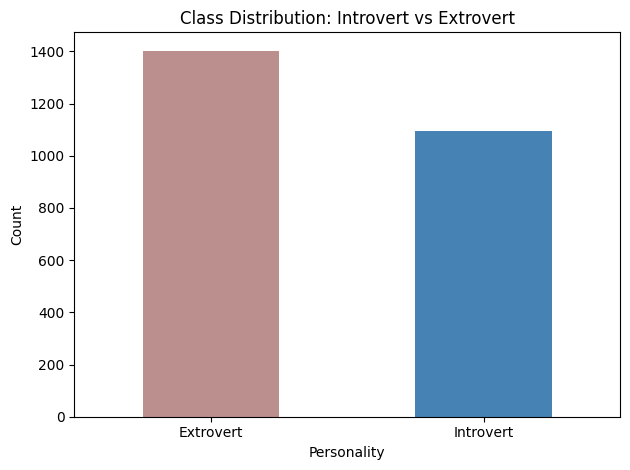

In [101]:
df['Personality'].value_counts().plot(kind='bar', color=['rosybrown', 'steelblue'])
plt.title('Class Distribution: Introvert vs Extrovert')
plt.xlabel('Personality')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Numeric Feature Distribution

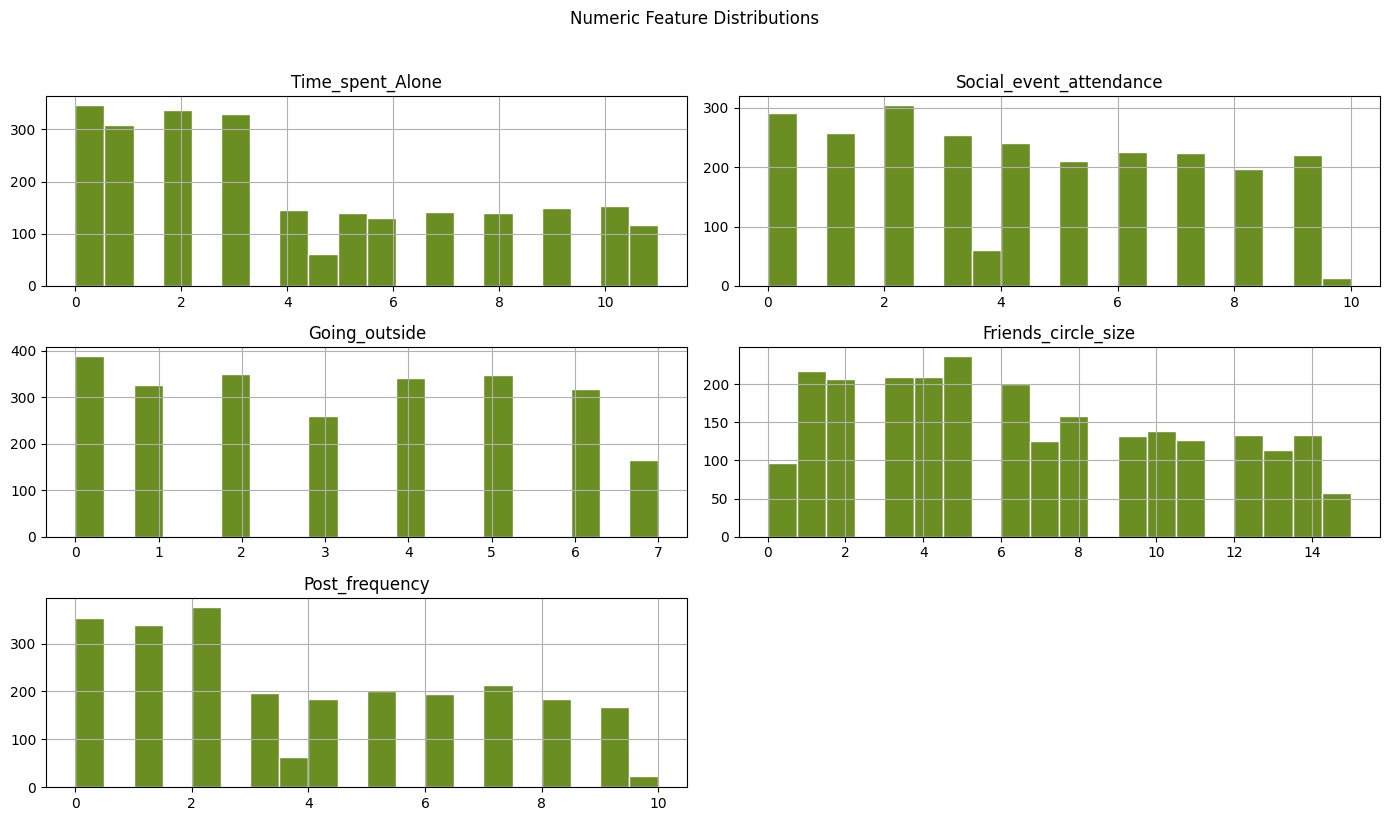

In [102]:
numerical_cols = [
    'Time_spent_Alone', 'Social_event_attendance',
    'Going_outside', 'Friends_circle_size', 'Post_frequency'
]

df[numerical_cols].hist(bins=20, figsize=(14, 8), color='olivedrab', edgecolor='white')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

### Numeric Feature vs Target

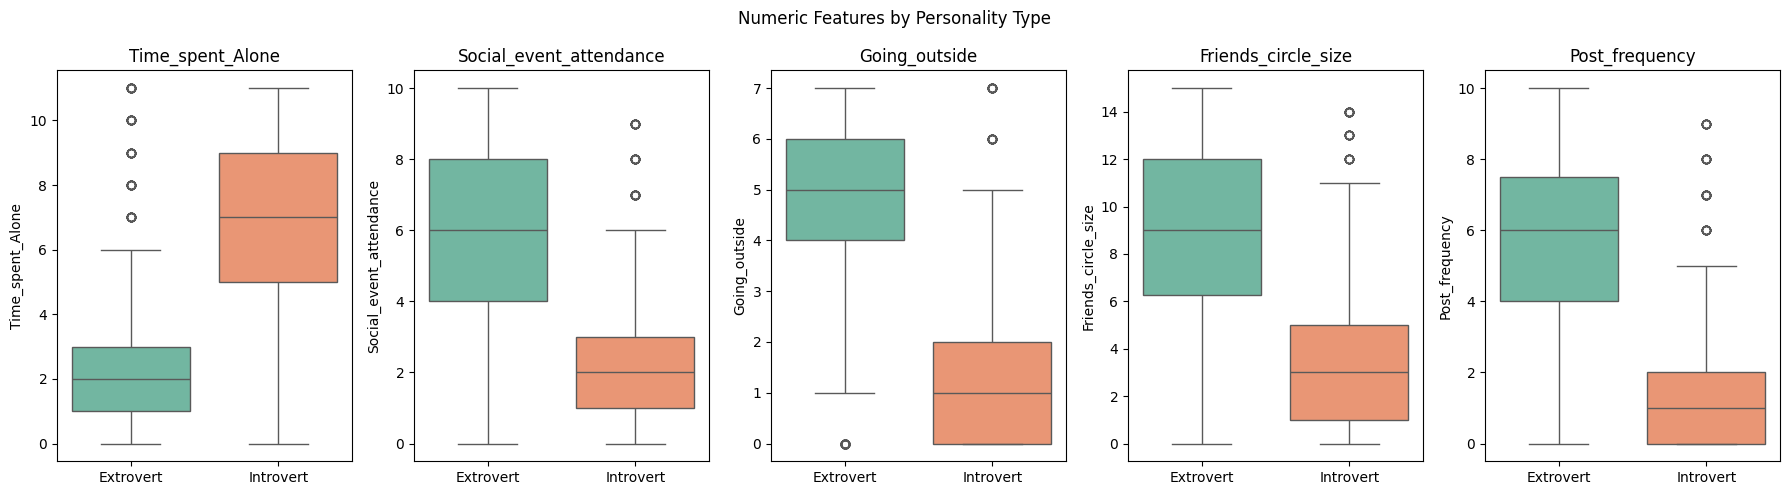

In [103]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(18, 5))

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(x='Personality', y=col, data=df, ax=ax, palette='Set2', hue='Personality')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Numeric Features by Personality Type')
plt.tight_layout()
plt.show()

### Categorical Feature vs Target

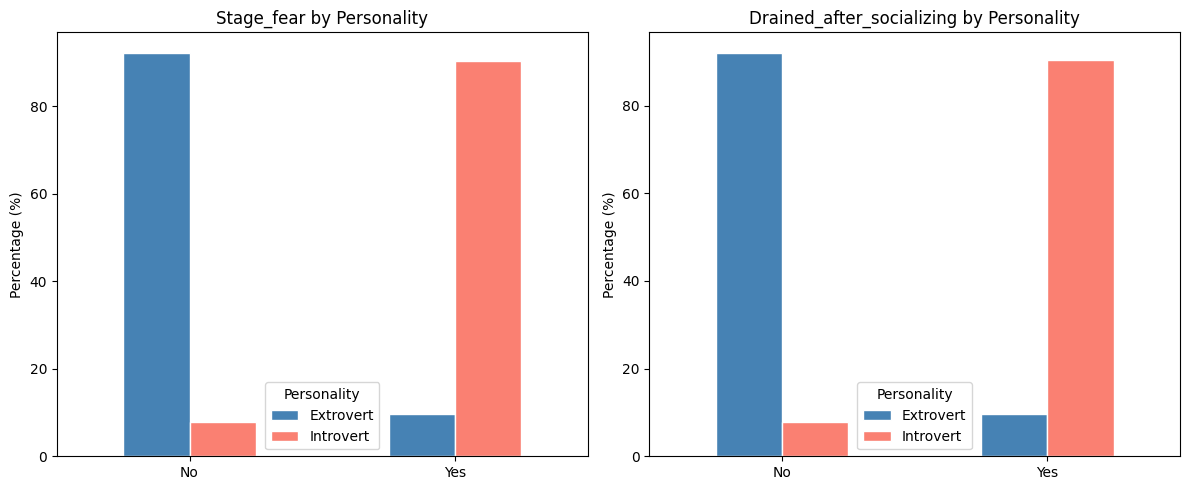

In [104]:
categorical_cols = ['Stage_fear', 'Drained_after_socializing']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, categorical_cols):
    ct = pd.crosstab(df[col], df['Personality'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
    ax.set_title(f'{col} by Personality')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.legend(title='Personality')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Feature Engineering

In [105]:
# Encoding binary categorical variables
binary_map = {'Yes': 1, 'No': 0}
for col in categorical_cols:
    df[col] = df[col].map(binary_map)

In [106]:
# Encode target variable
if 'Personality' in df.columns:
        df['Personality'] = df['Personality'].map(
            {'Extrovert': 1, 'Introvert': 0}
        )

### Correlation Heatmap

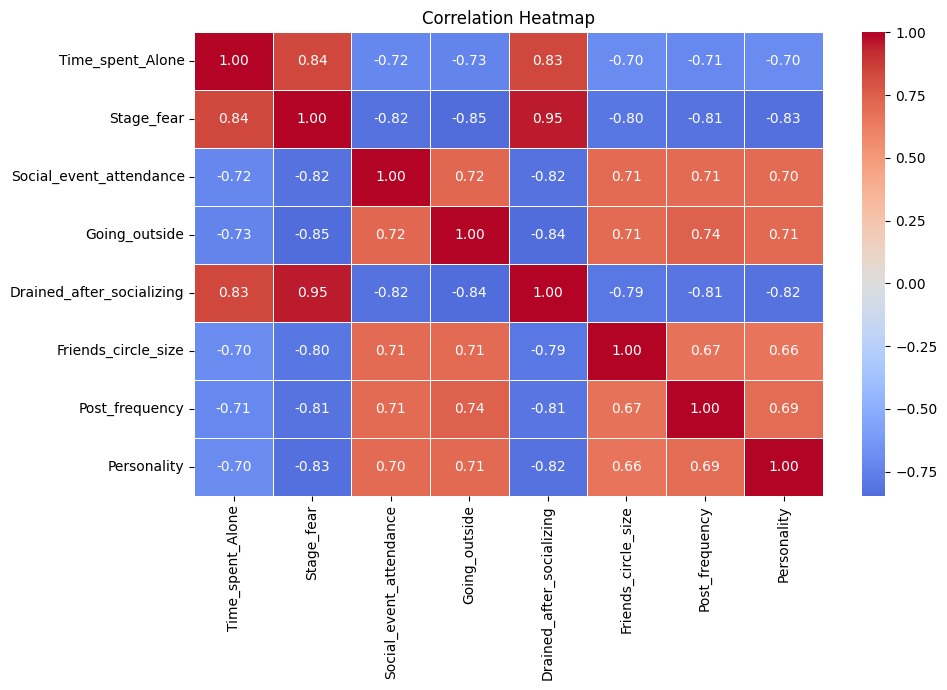

In [107]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Split data

In [108]:
X = df[['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
        'Friends_circle_size', 'Post_frequency', 'Stage_fear', 'Drained_after_socializing']]
y = df["Personality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train and Evaluate Model

In [109]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [110]:
y_pred = model.predict(X_test)

In [111]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.906
[[202  19]
 [ 28 251]]
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       221
           1       0.93      0.90      0.91       279

    accuracy                           0.91       500
   macro avg       0.90      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



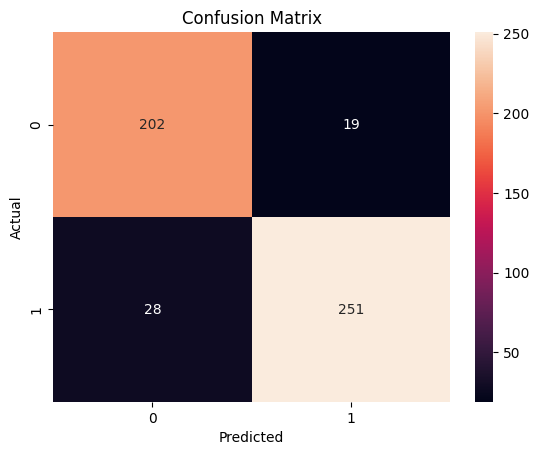

In [112]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Save the model

In [113]:
import pickle

with open("../model.pkl", "wb") as f:
    pickle.dump(model, f)